## Multivariate analyisis

### Import dependencies

In [2]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.spatial.distance import euclidean
from scipy.stats import f_oneway
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skbio.stats.distance import permanova 
from skbio.stats.distance import DistanceMatrix 
import matplotlib.pyplot as plt
import matplotlib.transforms
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings('ignore')

### Import data and preprocessing

In [3]:
# === Path ================================================================
FEATURES = Path(r"C:\Users\david\OneDrive - Università degli Studi di Parma\PhD\Projects\Coffee_leaf_infuses\data\processed\feature_table.csv")
METADATA = Path(r"C:\Users\david\OneDrive - Università degli Studi di Parma\PhD\Projects\Coffee_leaf_infuses\data\gcms\volatile_infuses_metadata.tsv")

output_dir = Path(".") / "outputs"
output_dir.mkdir(exist_ok=True)

# === Metadata ========================================================
sample_col = 'ATTRIBUTE_Sample'
temp_col = 'ATTRIBUTE_Extraction'
group_col = 'ATTRIBUTE_Group'

# === Import data ========================================================
print("\n" + "="*70)
print("DATA IMPORT")
print("="*70)

feat_df = pd.read_csv(FEATURES, index_col=0)
print(f"\n Feature table loaded: {feat_df.shape[0]} metabolites × {feat_df.shape[1]} samples")

meta_raw = pd.read_csv(METADATA, sep='\t')
print(f"Metadata loaded: {meta_raw.shape[0]} entries")

# === Verify metadata-features matching =======================================
print("\n" + "="*70)
print("METADATA-FEATURES CONSISTENCY CHECK")
print("="*70)

meta_raw = meta_raw[meta_raw[sample_col].isin(feat_df.columns)].copy()
samples_in_features = set(feat_df.columns)
samples_in_metadata = set(meta_raw[sample_col])
missing_in_metadata = samples_in_features - samples_in_metadata
missing_in_features = samples_in_metadata - samples_in_features

if missing_in_metadata:
    print(f"WARNING: {len(missing_in_metadata)} samples in features but NOT in metadata:")
    print(f"   {missing_in_metadata}")
else:
    print(f"All feature samples have metadata")

if missing_in_features:
    print(f"WARNING: {len(missing_in_features)} samples in metadata but NOT in features:")
    print(f"   {missing_in_features}")
else:
    print(f"All metadata samples are in features")

print(f"\nMetadata samples matched with features: {len(samples_in_metadata)}")

# === Split by extraction temperature ==========================================
print("\n" + "="*70)
print("DATASET SPLIT: HOT vs COLD")
print("="*70)

hot_cols = meta_raw.loc[meta_raw[temp_col].str.contains('hot', case=False, na=False), sample_col].tolist()
cold_cols = meta_raw.loc[meta_raw[temp_col].str.contains('cold', case=False, na=False), sample_col].tolist()

print(f"\nHOT samples: {len(hot_cols)}")
print(f"COLD samples: {len(cold_cols)}")

hot_df = feat_df[hot_cols].copy()
cold_df = feat_df[cold_cols].copy()

grp_map = meta_raw.set_index(sample_col)[group_col].rename('Group')

# === Check for NaN values ====================================================
print("\n" + "="*70)
print("NaN VALUE CHECK")
print("="*70)

def check_nan_values(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """
    Check for NaN values in the dataset.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Feature matrix to check
    dataset_name : str
        Name of the dataset (for printing)
        
    Returns:
    --------
    pd.DataFrame
        Input dataframe unchanged (for chaining)
    """
    nan_count = df.isna().sum().sum()
    nan_percentage = (nan_count / (df.shape[0] * df.shape[1])) * 100
    
    if nan_count > 0:
        print(f"\n {dataset_name}: {nan_count} NaN values ({nan_percentage:.2f}%)")
        nan_per_feature = df.isna().sum(axis=1)
        nan_features = nan_per_feature[nan_per_feature > 0]
        print(f"    Features with NaN: {len(nan_features)}")
        print(f"    Max NaN per feature: {nan_features.max()}")
        
        # Fill NaN with 0 (common for missing abundances)
        print(f"    → Filling NaN with 0...")
        df = df.fillna(0)
    else:
        print(f"✓ {dataset_name}: No NaN values detected")
    
    return df

hot_df = check_nan_values(hot_df, "HOT dataset")
cold_df = check_nan_values(cold_df, "COLD dataset")

# === FEATURE FILTERING ===============================================
print("\n" + "="*70)
print("FEATURE FILTERING: Removing empty features")
print("="*70)

def filter_empty_features(df: pd.DataFrame, 
                         min_prevalence: float = 0.2,
                         min_abundance: float = 0,
                         dataset_name: str = "Dataset") -> pd.DataFrame:
    """
    Filter features (rows) based on prevalence and abundance thresholds.
    
    A feature is retained if it appears (with value > min_abundance) in at least
    min_prevalence fraction of samples. This is standard in metabolomics to remove
    rare or missing features that may introduce noise.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Feature matrix (features × samples)
    min_prevalence : float
        Minimum fraction of samples where feature must be detected.
        Default: 0.2 (feature must be in ≥20% of samples)
        Range: [0, 1]
    min_abundance : float
        Minimum value to consider a feature "detected"
        Default: 0 (any value > 0)
    dataset_name : str
        Name of dataset for logging
        
    Returns:
    --------
    pd.DataFrame
        Filtered feature matrix (only features meeting thresholds)
    """
    n_features_original = df.shape[0]
    n_samples = df.shape[1]
    
    # Calculate prevalence: fraction of samples where feature is detected
    detected = (df > min_abundance).sum(axis=1)
    prevalence = detected / n_samples
    
    # Apply filter
    mask = prevalence >= min_prevalence
    df_filtered = df[mask].copy()
    
    n_features_filtered = df_filtered.shape[0]
    n_removed = n_features_original - n_features_filtered
    
    print(f"\n📊 {dataset_name} Filtering Results:")
    print(f"   Original features: {n_features_original}")
    print(f"   Removed: {n_removed} ({100*n_removed/n_features_original:.1f}%)")
    print(f"   Retained: {n_features_filtered} ({100*n_features_filtered/n_features_original:.1f}%)")
    print(f"   Samples: {n_samples}")
    print(f"   Prevalence threshold: {min_prevalence*100:.1f}% (feature in ≥{int(np.ceil(min_prevalence*n_samples))} samples)")
    
    return df_filtered

# Apply filters
hot_df = filter_empty_features(hot_df, min_prevalence=0.2, dataset_name="HOT")
cold_df = filter_empty_features(cold_df, min_prevalence=0.2, dataset_name="COLD")

# === Summary of filtering ====================================================
print("\n" + "="*70)
print("FEATURE FILTERING SUMMARY")
print("="*70)

summary_data = {
    'Dataset': ['HOT', 'COLD'],
    'Features Retained': [hot_df.shape[0], cold_df.shape[0]],
    'Samples': [hot_df.shape[1], cold_df.shape[1]]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

# === Data preprocessing ===================================================
print("\n" + "="*70)
print("DATA AUTOSCALING (STANDARDIZATION)")
print("="*70)

def process_data(df: pd.DataFrame, dataset_name: str = "Dataset") -> pd.DataFrame:
    """
    Apply autoscaling (standardization) to the feature data.
    
    Autoscaling ensures each metabolite (feature) has mean=0 and std=1 across all
    samples. This is crucial for multivariate analysis methods like PCA and PLS
    that are sensitive to variable scaling.
    
    Process:
    --------
    1. Transpose matrix from (metabolites × samples) to (samples × metabolites)
    2. Apply StandardScaler to each column (metabolite) independently
    3. Each metabolite gets: (value - mean) / std
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input feature matrix (metabolites × samples)
    dataset_name : str
        Name of dataset for logging
        
    Returns:
    --------
    pd.DataFrame
        Autoscaled feature matrix (samples × metabolites)
        Each metabolite: mean≈0, std≈1
    """
    print(f"\n{dataset_name}:")
    print(f"  Input shape: {df.shape[0]} metabolites × {df.shape[1]} samples")
    
    # Step 1: Transpose to (samples × metabolites)
    df_transposed = df.T
    print(f"  Transposed: {df_transposed.shape[0]} samples × {df_transposed.shape[1]} metabolites")
    
    # Step 2: Apply StandardScaler
    # StandardScaler().fit_transform() scales COLUMNS independently
    # So each metabolite (column) gets mean=0, std=1 across samples
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(df_transposed)
    
    # Step 3: Create DataFrame with proper index/columns
    scaled_df = pd.DataFrame(
        scaled_array,
        index=df.columns,      # Sample names (from original columns)
        columns=df.index       # Metabolite names (from original index)
    )
    
    # === VALIDATION: Per-metabolite statistics ===============================
    means_per_metabolite = scaled_df.mean(axis=0)
    stds_per_metabolite = scaled_df.std(axis=0)
    
    print(f"\nAutoscaling Validation (per metabolite):")
    print(f"     Means: min={means_per_metabolite.min():.2e}, max={means_per_metabolite.max():.2e} (expect ≈0)")
    print(f"     Stds:  min={stds_per_metabolite.min():.4f}, max={stds_per_metabolite.max():.4f} (expect ≈1)")
    
    # Strict validation
    if not np.allclose(means_per_metabolite, 0, atol=1e-10):
        print(f"WARNING: Some metabolites have non-zero mean!")
    
    if not np.allclose(stds_per_metabolite, 1, atol=1e-10):
        print(f"WARNING: Some metabolites have non-unit std!")
    
    # Global statistics
    global_mean = scaled_df.values.mean()
    global_std = scaled_df.values.std()
    print(f"\n  Global statistics:")
    print(f"     Mean: {global_mean:.6f}")
    print(f"     Std: {global_std:.6f}")
    print(f"     Output shape: {scaled_df.shape[0]} samples × {scaled_df.shape[1]} metabolites")
    
    return scaled_df

# Apply autoscaling
hot_scaled = process_data(hot_df, dataset_name="HOT Dataset")
cold_scaled = process_data(cold_df, dataset_name="COLD Dataset")

# === Final data summary =====================================================
print("\n" + "="*70)
print("PREPROCESSING COMPLETE - FINAL DATA SUMMARY")
print("="*70)

print("\n HOT Dataset (autoscaled):")
print(f"   Shape: {hot_scaled.shape[0]} samples × {hot_scaled.shape[1]} metabolites")
print(f"   Sample names: {list(hot_scaled.index[:5])}... (showing first 5)")
print(f"   Metabolite names: {list(hot_scaled.columns[:5])}... (showing first 5)")

print("\n COLD Dataset (autoscaled):")
print(f"   Shape: {cold_scaled.shape[0]} samples × {cold_scaled.shape[1]} metabolites")
print(f"   Sample names: {list(cold_scaled.index[:5])}... (showing first 5)")
print(f"   Metabolite names: {list(cold_scaled.columns[:5])}... (showing first 5)")

# === Optional: Save preprocessed data ========================================
print("\n" + "="*70)
print("OPTIONAL: SAVING PREPROCESSED DATA")
print("="*70)

output_dir = Path(".") / "outputs"
output_dir.mkdir(exist_ok=True)

try:
    hot_scaled.to_csv(output_dir / "hot_scaled.csv")
    cold_scaled.to_csv(output_dir / "cold_scaled.csv")
    print(f"\n✓ Preprocessed data saved to {output_dir}/")
    print(f"  - hot_scaled.csv")
    print(f"  - cold_scaled.csv")
except Exception as e:
    print(f"\n Error saving files: {e}")

# === Display sample data ====================================================
print("\n" + "="*70)
print("SAMPLE DATA")
print("="*70)

print("\nHOT Dataset (first 5 samples × first 5 metabolites):")
print(hot_scaled.iloc[:5, :5])

print("\nCOLD Dataset (first 5 samples × first 5 metabolites):")
print(cold_scaled.iloc[:5, :5])

print("\n" + "="*70)
print("PREPROCESSING COMPLETE")
print("="*70 + "\n")


DATA IMPORT

 Feature table loaded: 92 metabolites × 43 samples
Metadata loaded: 30 entries

METADATA-FEATURES CONSISTENCY CHECK
   {'Compound', 'CAS_ID', 'SMILES', 'NPCpathway', 'Delta_LRI', 'NPCclass', 'Key Odorant ', 'LRI Exp', 'NPCsuperclass', 'LRI Teo', 'RT', 'InChIKey', 'Odour'}
All metadata samples are in features

Metadata samples matched with features: 30

DATASET SPLIT: HOT vs COLD

HOT samples: 15
COLD samples: 15

NaN VALUE CHECK
✓ HOT dataset: No NaN values detected
✓ COLD dataset: No NaN values detected

FEATURE FILTERING: Removing empty features

📊 HOT Filtering Results:
   Original features: 92
   Removed: 14 (15.2%)
   Retained: 78 (84.8%)
   Samples: 15
   Prevalence threshold: 20.0% (feature in ≥3 samples)

📊 COLD Filtering Results:
   Original features: 92
   Removed: 30 (32.6%)
   Retained: 62 (67.4%)
   Samples: 15
   Prevalence threshold: 20.0% (feature in ≥3 samples)

FEATURE FILTERING SUMMARY

Dataset  Features Retained  Samples
    HOT                 78     

### PERMANOVA and PCA


PCA ANALYSIS WITH PERMANOVA AND PERMDISP

PCA ANALYSIS: Hot infuses
Explained variance - PC1: 38.5%
Explained variance - PC2: 27.8%
Total (PC1+PC2): 66.3%

--- Statistical Tests on PC1-PC2 Space ---

--- PERMDISP Test: Hot infuses (PC space) ---
F-statistic: 1.9308
p-value: 0.1818
✓ Groups have homogeneous dispersions (p ≥ 0.05)

--- PERMANOVA Test: Hot infuses (PC space) ---
method name                PERMANOVA
test statistic name         pseudo-F
sample size                       15
number of groups                   5
test statistic            242.201756
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object
✓ Results saved to hot_permanova.txt

PCA ANALYSIS: Cold infuses
Explained variance - PC1: 51.3%
Explained variance - PC2: 30.8%
Total (PC1+PC2): 82.1%

--- Statistical Tests on PC1-PC2 Space ---

--- PERMDISP Test: Cold infuses (PC space) ---
F-statistic: 4.9093
p-value: 0.0189
⚠️  WARNING: Significant difference in gro

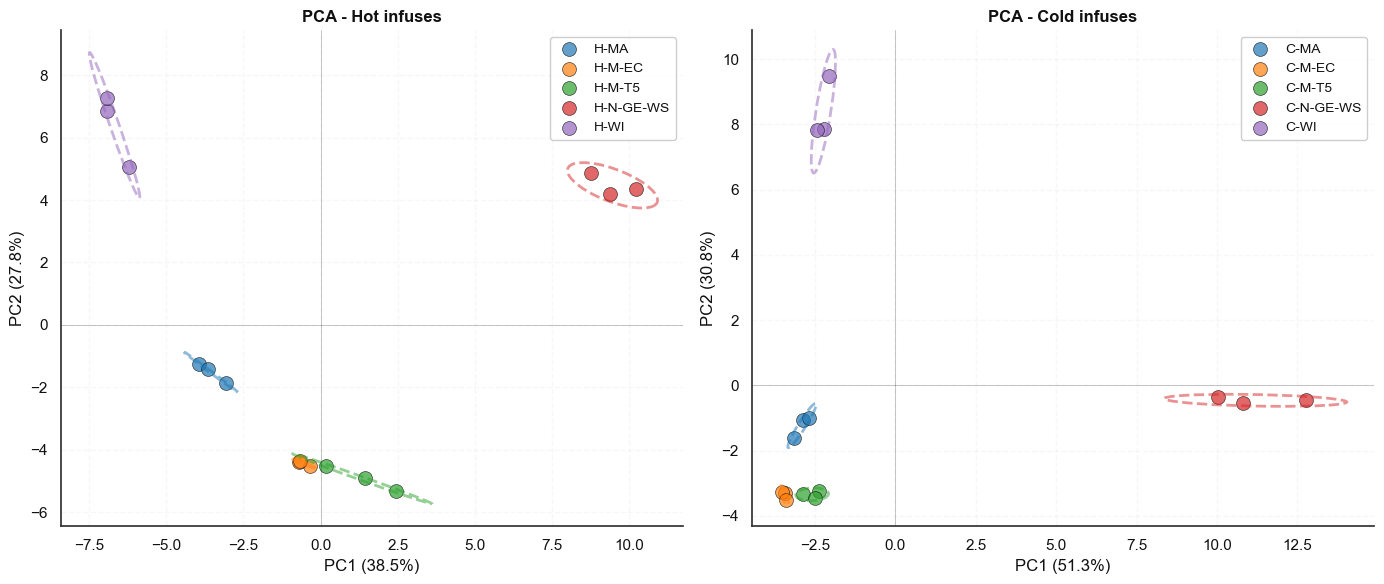

✓ Saved: outputs\PCA\pca_biplots.png
✓ Saved: outputs\PCA\pca_biplots.svg


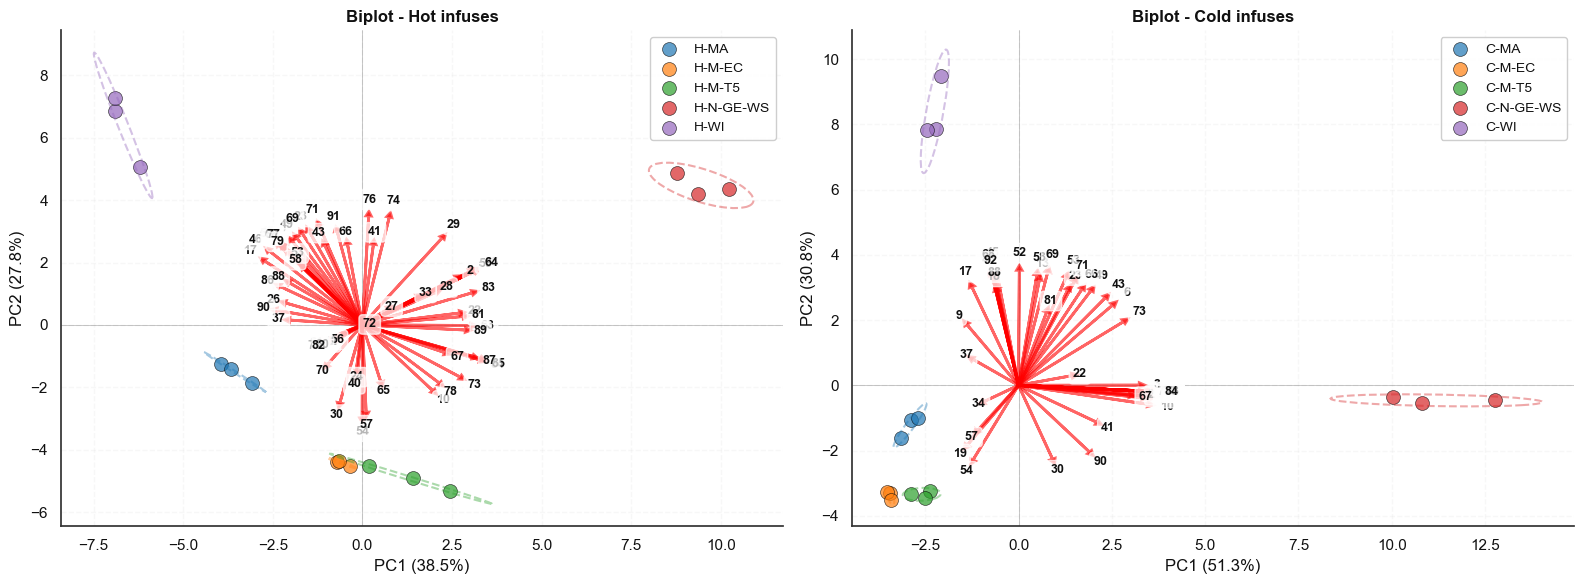


ANALYSIS COMPLETE!


In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

OUTPUT_DIR = Path("outputs/PCA")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Plot styling: set a white background style (no grey axes background)
sns.set_style('whitegrid')  # white-based grid; alternatives: 'white', 'ticks'
sns.set_context('notebook')

# Force white figure and axes backgrounds to avoid any grey patches
plt.rcParams.update({
    'figure.facecolor': '#ffffff',   # background outside axes
    'axes.facecolor': '#ffffff',     # plotting area background
    'axes.edgecolor': '#333333',
    'axes.labelcolor': '#111111',
    'xtick.color': '#111111',
    'ytick.color': '#111111',
    'grid.color': '#e6e6e6',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
    'text.color': '#111111',
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#cccccc'
})

# Colors for groups
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
FIGURE_DPI = 300
FIGURE_FORMAT = ['png', 'svg']

# Analysis parameters
PCA_COMPONENTS = 2
PERMANOVA_PERMUTATIONS = 999
PERMDISP_ALPHA = 0.05
CONFIDENCE_LEVEL = 2.0  # 2 sigma

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def confidence_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """
    Plot confidence ellipse for a 2D distribution
    """
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std

    transf = matplotlib.transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean[0], mean[1])

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)


def save_figure(fig, prefix, formats=FIGURE_FORMAT, dpi=FIGURE_DPI):
    """
    Save figure in multiple formats
    """
    for fmt in formats:
        filepath = OUTPUT_DIR / f"{prefix}.{fmt}"
        fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
        print(f"✓ Saved: {filepath}")

# ============================================================================
# STATISTICAL TESTS
# ============================================================================

def run_permdisp(df: pd.DataFrame, group_series: pd.Series, title: str):
    """
    PERMDISP test: evaluates homogeneity of group dispersions
    """
    common_ids = df.index.intersection(group_series.index)
    df = df.loc[common_ids]
    group_series = group_series.loc[common_ids]

    print(f"\n--- PERMDISP Test: {title} ---")

    # Calculate group centroids
    group_centroids = {}
    for group in group_series.unique():
        members = df[group_series == group]
        centroid = members.mean().values
        group_centroids[group] = centroid

    # Distances to centroid
    distances_to_centroid = []
    group_labels = []
    for sample_id in df.index:
        group = group_series[sample_id]
        centroid = group_centroids[group]
        dist = euclidean(df.loc[sample_id].values, centroid)
        distances_to_centroid.append(dist)
        group_labels.append(group)

    dist_by_group = pd.DataFrame({
        'Group': group_labels,
        'Distance': distances_to_centroid
    })

    grouped_distances = [g['Distance'].values for _, g in dist_by_group.groupby('Group')]
    f_stat, p_val = f_oneway(*grouped_distances)

    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.4f}")
    if p_val < PERMDISP_ALPHA:
        print(f"⚠️  WARNING: Significant difference in group dispersions (p < {PERMDISP_ALPHA})")
        print("   → PERMANOVA results should be interpreted with caution")
    else:
        print(f"✓ Groups have homogeneous dispersions (p ≥ {PERMDISP_ALPHA})")

    return {'F-statistic': f_stat, 'p-value': p_val, 'data': dist_by_group}


def run_permanova(df: pd.DataFrame, group_series: pd.Series, title: str, save_prefix: str):
    """
    PERMANOVA analysis: tests for significant differences between groups
    """
    df = df.copy()
    group_series = group_series.copy()

    print(f"\n--- PERMANOVA Test: {title} ---")

    common_ids = df.index.intersection(group_series.index)
    df = df.loc[common_ids]
    group_series = group_series.loc[common_ids]

    df_with_groups = df.copy()
    df_with_groups['Group'] = group_series

    try:
        dist_matrix = DistanceMatrix.from_iterable(
            df.values,
            metric=euclidean,
            keys=df.index
        )

        result = permanova(dist_matrix, df_with_groups['Group'], permutations=PERMANOVA_PERMUTATIONS)

        print(result)

        with open(OUTPUT_DIR / f"{save_prefix}_permanova.txt", 'w') as f:
            f.write(f"PERMANOVA Result: {title}\n")
            f.write("=" * 70 + "\n")
            f.write(f"Permutations: {PERMANOVA_PERMUTATIONS}\n\n")
            f.write(str(result))

        print(f"✓ Results saved to {save_prefix}_permanova.txt")

        return result

    except Exception as e:
        print(f"[PERMANOVA ERROR] {e}")
        return None

# ============================================================================
# PCA ANALYSIS
# ============================================================================

def run_pca_analysis(df_scaled: pd.DataFrame, group_series: pd.Series,
                     title: str, save_prefix: str):
    """
    Complete PCA analysis with PERMANOVA and PERMDISP on PC space
    """
    common_ids = df_scaled.index.intersection(group_series.index)
    df_scaled = df_scaled.loc[common_ids]
    group_series = group_series.loc[common_ids]

    pca = PCA(n_components=PCA_COMPONENTS)
    pcs = pca.fit_transform(df_scaled.values)

    pca_df = pd.DataFrame(
        pcs[:, :PCA_COMPONENTS],
        index=df_scaled.index,
        columns=[f'PC{i+1}' for i in range(PCA_COMPONENTS)]
    )

    print(f"\n{'='*70}")
    print(f"PCA ANALYSIS: {title}")
    print(f"{'='*70}")
    print(f"Explained variance - PC1: {pca.explained_variance_ratio_[0]:.1%}")
    print(f"Explained variance - PC2: {pca.explained_variance_ratio_[1]:.1%}")
    print(f"Total (PC1+PC2): {pca.explained_variance_ratio_[:2].sum():.1%}")

    print(f"\n--- Statistical Tests on PC1-PC2 Space ---")
    permdisp_result = run_permdisp(pca_df, group_series, f'{title} (PC space)')
    permanova_result = run_permanova(pca_df, group_series, f'{title} (PC space)', save_prefix)

    return pca, pca_df, permdisp_result, permanova_result, df_scaled

# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

def plot_pca_scores(pca, pca_df: pd.DataFrame, group_series: pd.Series,
                    title: str, ax):
    """
    Plot PCA scores with confidence ellipses
    """
    groups = pca_df.index.map(group_series)

    for i, group in enumerate(groups.unique()):
        mask = groups == group
        color = COLORS[i % len(COLORS)]

        ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                   label=group, s=100, alpha=0.7, color=color,
                   edgecolors='black', linewidth=0.5)

        group_data = pca_df.loc[mask, ['PC1', 'PC2']]
        mean = group_data.mean().values
        cov = group_data.cov().values
        confidence_ellipse(mean, cov, ax, n_std=CONFIDENCE_LEVEL,
                           edgecolor=color, facecolor='none',
                           linestyle='--', alpha=0.5, linewidth=2)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)


def plot_biplot(pca, df_scaled: pd.DataFrame, pca_df: pd.DataFrame,
                group_series: pd.Series, title: str, ax):
    """
    Create a biplot showing PCA scores and variable loadings
    """
    groups = pca_df.index.map(group_series)

    for i, group in enumerate(groups.unique()):
        mask = groups == group
        color = COLORS[i % len(COLORS)]

        ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                   label=group, s=100, alpha=0.7, color=color,
                   edgecolors='black', linewidth=0.5)

        group_data = pca_df.loc[mask, ['PC1', 'PC2']]
        mean = group_data.mean().values
        cov = group_data.cov().values
        confidence_ellipse(mean, cov, ax, n_std=CONFIDENCE_LEVEL,
                           edgecolor=color, facecolor='none',
                           linestyle='--', alpha=0.4, linewidth=1.5)

    # Plot loadings (variable arrows)
    loadings = pca.components_[:2, :].T
    loading_matrix = loadings * np.sqrt(pca.explained_variance_[:2])

    scale_factor = 3.5

    for i, feature in enumerate(df_scaled.columns):
        ax.arrow(0, 0,
                 loading_matrix[i, 0] * scale_factor,
                 loading_matrix[i, 1] * scale_factor,
                 head_width=0.15, head_length=0.15, fc='red', ec='red',
                 alpha=0.6, linewidth=2, zorder=5)

        label_x = loading_matrix[i, 0] * scale_factor * 1.15
        label_y = loading_matrix[i, 1] * scale_factor * 1.15

        ax.text(label_x, label_y, feature, fontsize=9, ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
                fontweight='bold', zorder=6)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(f'Biplot - {title}', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)

# ============================================================================
# MAIN ANALYSIS
# ============================================================================

def main(hot_scaled: pd.DataFrame, cold_scaled: pd.DataFrame,
         grp_map: pd.Series):
    """
    Main analysis function
    """
    print("\n" + "="*70)
    print("PCA ANALYSIS WITH PERMANOVA AND PERMDISP")
    print("="*70)

    # HOT extraction
    pca_hot, hot_pca_df, permdisp_hot, perm_hot, hot_orig = run_pca_analysis(
        hot_scaled, grp_map, 'Hot infuses', 'hot'
    )

    # COLD extraction
    pca_cold, cold_pca_df, permdisp_cold, perm_cold, cold_orig = run_pca_analysis(
        cold_scaled, grp_map, 'Cold infuses', 'cold'
    )

    # PCA score plots (ensure white backgrounds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#ffffff')
    for ax in axes:
        ax.set_facecolor('#ffffff')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plot_pca_scores(pca_hot, hot_pca_df, grp_map, 'PCA - Hot infuses', axes[0])
    plot_pca_scores(pca_cold, cold_pca_df, grp_map, 'PCA - Cold infuses', axes[1])

    plt.tight_layout()
    save_figure(fig, 'pca_scores')
    plt.show()

    # Biplots (ensure white backgrounds)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#ffffff')
    for ax in axes:
        ax.set_facecolor('#ffffff')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plot_biplot(pca_hot, hot_orig, hot_pca_df, grp_map, 'Hot infuses', axes[0])
    plot_biplot(pca_cold, cold_orig, cold_pca_df, grp_map, 'Cold infuses', axes[1])

    plt.tight_layout()
    save_figure(fig, 'pca_biplots')
    plt.show()

    print("\n" + "="*70)
    print("ANALYSIS COMPLETE!")
    print("="*70)

    return {
        'hot': {
            'pca': pca_hot,
            'scores': hot_pca_df,
            'permdisp': permdisp_hot,
            'permanova': perm_hot
        },
        'cold': {
            'pca': pca_cold,
            'scores': cold_pca_df,
            'permdisp': permdisp_cold,
            'permanova': perm_cold
        }
    }

# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    """
    Usage:
    results = main(hot_scaled, cold_scaled, grp_map)
    """
    # Uncomment and supply your data variables to run:
    results = main(hot_scaled, cold_scaled, grp_map)
    pass

### Heatmap

In [49]:
def create_heatmap(df_scaled: pd.DataFrame, group_series: pd.Series, 
                   title: str, save_prefix: str, top_n: int = None,
                   figsize: tuple = (12, 10), compound_names: pd.Series = None):
    """
    Create clustered heatmap with hierarchical clustering
    
    Parameters:
    -----------
    df_scaled : DataFrame with scaled metabolite abundances (samples x features)
    group_series : Series with group labels for each sample
    title : Title for the plot
    save_prefix : Prefix for saved files
    top_n : Number of top variables to include (based on variance). If None, uses all features
    figsize : Figure size (width, height)
    compound_names : Series mapping feature IDs to compound names
    """
    
    # Align indices
    common_ids = df_scaled.index.intersection(group_series.index)
    df_scaled = df_scaled.loc[common_ids]
    group_series = group_series.loc[common_ids]
    
    # Filter: keep only features with at least one non-zero value
    df_nonzero = df_scaled.loc[:, (df_scaled != 0).any(axis=0)]
    
    # Select features
    feature_variance = df_nonzero.var(axis=0)
    if top_n is None:
        df_top = df_nonzero.copy()
        features_text = f"all features with non-zero values ({df_nonzero.shape[1]})"
    else:
        top_features = feature_variance.nlargest(top_n).index
        df_top = df_nonzero[top_features].copy()
        features_text = f"top {top_n} most variable features"
    
    print(f"\n{'='*70}")
    print(f"HEATMAP ANALYSIS: {title}")
    print(f"{'='*70}")
    print(f"Total features (original): {df_scaled.shape[1]}")
    print(f"Features with non-zero values: {df_nonzero.shape[1]}")
    print(f"Selected: {features_text}")
    print(f"Samples: {df_top.shape[0]}")
    
    # Prepare data for heatmap (transpose: features as rows, samples as columns)
    df_heatmap = df_top.T
    
    # Map feature IDs to compound names if provided
    if compound_names is not None:
        df_heatmap.index = df_heatmap.index.map(
            lambda x: compound_names.get(x, x) if x in compound_names.index else x
        )
    
    # Create color mapping for groups
    groups = group_series.sort_values().unique()
    palette = sns.color_palette("deep", n_colors=len(groups))
    group_colors = {group: palette[i] for i, group in enumerate(groups)}
    
    # Create column colors (sample annotation)
    col_colors = group_series.map(group_colors)
    
    # Create clustermap
    sns.set_theme(style="white", font_scale=0.8)
    
    g = sns.clustermap(
        df_heatmap,
        method='ward',           # Hierarchical clustering method
        metric='euclidean',      # Distance metric
        cmap='vlag',        # Color palette (red-yellow-blue reversed)
        center=0,                # Center colormap at 0
        col_colors=col_colors,   # Sample group colors
        figsize=figsize,
        cbar_kws={'label': 'Scaled Abundance'},
        dendrogram_ratio=0.15,
        colors_ratio=0.03,
        linewidths=0,
        xticklabels=True,
        yticklabels=True
    )
    
    # Adjust labels
    g.ax_heatmap.set_xlabel('Samples', fontsize=10)
    g.ax_heatmap.set_ylabel('Metabolites', fontsize=10)
    g.ax_heatmap.set_title(title, fontsize=12, pad=20)
    
    # Rotate x-axis labels
    plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90, fontsize=7)
    plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), fontsize=7)
    
    # Add legend for groups
    handles = [plt.Line2D([0], [0], marker='o', color='w', 
                         markerfacecolor=color, markersize=10, label=group)
              for group, color in group_colors.items()]
    g.ax_heatmap.legend(handles=handles, title='Groups', 
                       bbox_to_anchor=(1.30, 1), loc='upper left',
                       frameon=True, fontsize=8)
    
    # Save figure
    os.makedirs("outputs/Heatmap", exist_ok=True)
    suffix = f"_top{top_n}" if top_n else "_all"
    plt.savefig(f"outputs/Heatmap/{save_prefix}_heatmap{suffix}.png", 
                dpi=300, bbox_inches='tight')
    plt.savefig(f"outputs/Heatmap/{save_prefix}_heatmap{suffix}.svg", 
                bbox_inches='tight')
    
    print(f"✓ Heatmap saved: outputs/Heatmap/{save_prefix}_heatmap{suffix}.*")
    
    plt.show()
    
    return g, df_top


# === MAIN EXECUTION ==========================================================

if __name__ == '__main__':
    
    print("\n" + "="*70)
    print("HEATMAP ANALYSIS")
    print("="*70)
    
    # Hot extraction - All features
    print("\n### HOT EXTRACTION - All Features ###")
    g_hot, top_hot = create_heatmap(
        hot_scaled, 
        grp_map, 
        'Heatmap - Hot Extraction (All Features)',
        'hot',
        top_n=None,
        figsize=(14, 12),
        compound_names=compound_names
    )
    
    # Cold extraction - All features
    print("\n### COLD EXTRACTION - All Features ###")
    g_cold, top_cold = create_heatmap(
        cold_scaled,
        grp_map,
        'Heatmap - Cold Extraction (All Features)',
        'cold',
        top_n=None,
        figsize=(14, 12),
        compound_names=compound_names 
    )
    
    print("\n" + "="*70)
    print("HEATMAP ANALYSIS COMPLETE!")
    print("="*70)
    print("\nAll heatmaps and data files have been saved to outputs/Heatmap/")


HEATMAP ANALYSIS

### HOT EXTRACTION - All Features ###


NameError: name 'compound_names' is not defined

## Trash

In [ ]:
## OLD PCA
# === PERMDISP - Homogeneity of Dispersions Test ==============================
def run_permdisp(df: pd.DataFrame, group_series: pd.Series, title: str):
    """
    PERMDISP test: evaluates homogeneity of group dispersions
    (multivariate spread around group centroids)
    """
    # Align indices
    common_ids = df.index.intersection(group_series.index)
    df = df.loc[common_ids]
    group_series = group_series.loc[common_ids]
    
    # Calculate group centroids
    group_centroids = {}
    for group in group_series.unique():
        members = df[group_series == group]
        centroid = members.mean().values
        group_centroids[group] = centroid
    
    # Calculate distances from each sample to its group centroid
    distances_to_centroid = []
    group_labels = []
    
    for sample_id in df.index:
        group = group_series[sample_id]
        centroid = group_centroids[group]
        dist = euclidean(df.loc[sample_id].values, centroid)
        distances_to_centroid.append(dist)
        group_labels.append(group)
    
    # ANOVA on distances
    dist_by_group = pd.DataFrame({
        'Group': group_labels, 
        'Distance': distances_to_centroid
    })
    
    grouped_distances = [
        g['Distance'].values for _, g in dist_by_group.groupby('Group')
    ]
    
    f_stat, p_val = f_oneway(*grouped_distances)
    
    # Print results
    print(f"\n=== PERMDISP Results ({title}) ===")
    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.4f}")
    if p_val < 0.05:
        print("WARNING: Significant difference in group dispersions (p < 0.05)")
        print("PERMANOVA results should be interpreted with caution")
    else:
        print("Groups have homogeneous dispersions (p ≥ 0.05)")
    
    return {'F-statistic': f_stat, 'p-value': p_val, 'data': dist_by_group}

# === PERMANOVA Analysis ======================================================
def run_permanova(df: pd.DataFrame, group_series: pd.Series, title: str, save_prefix: str):
    """PERMANOVA analysis"""
    df = df.copy()
    group_series = group_series.copy()
    
    common_ids = df.index.intersection(group_series.index)
    df = df.loc[common_ids]
    group_series = group_series.loc[common_ids]
    
    df_with_groups = df.copy()
    df_with_groups['Group'] = group_series
    
    try:
        dist_matrix = DistanceMatrix.from_iterable(
            df.values, 
            metric=euclidean, 
            keys=df.index
        )
        
        result = permanova(dist_matrix, df_with_groups['Group'], permutations=999)
        
        print(f"\n=== PERMANOVA Results ({title}) ===")
        print(result)
        
        # Save results
        os.makedirs("outputs/PCA", exist_ok=True)
        with open(f"outputs/PCA/{save_prefix}_permanova.txt", 'w') as f:
            f.write(f"PERMANOVA result for {title}:\n")
            f.write(str(result))
        
        return result
            
    except Exception as e:
        print(f"[PERMANOVA ERROR] {e}")
        return None

# === PCA Analysis and Plotting ===============================================
def run_pca_analysis(df_scaled: pd.DataFrame, group_series: pd.Series, 
                     title: str, save_prefix: str):
    """
    Complete PCA analysis with PERMANOVA on PC space
    """
    # Align indices
    common_ids = df_scaled.index.intersection(group_series.index)
    df_scaled = df_scaled.loc[common_ids]
    group_series = group_series.loc[common_ids]
    
    # Perform PCA
    pca = PCA()
    pcs = pca.fit_transform(df_scaled.values)
    
    # Create DataFrame with PC scores
    pca_df = pd.DataFrame(
        pcs[:, :2], 
        index=df_scaled.index, 
        columns=['PC1', 'PC2']
    )
    
    print(f"\n{'='*70}")
    print(f"PCA ANALYSIS: {title}")
    print(f"{'='*70}")
    print(f"Explained variance - PC1: {pca.explained_variance_ratio_[0]:.1%}")
    print(f"Explained variance - PC2: {pca.explained_variance_ratio_[1]:.1%}")
    print(f"Total explained variance (PC1+PC2): {pca.explained_variance_ratio_[:2].sum():.1%}")
    
    # Statistical tests on PC space
    print(f"\n--- Statistical Tests on PC1-PC2 Space ---")
    permdisp_result = run_permdisp(pca_df, group_series, f'{title} (PC space)')
    permanova_result = run_permanova(pca_df, group_series, f'{title} (PC space)', save_prefix)
    
    return pca, pca_df, permdisp_result, permanova_result

# === RUN PCA AND TESTS =======================================================

print("\n" + "="*70)
print("PCA ANALYSIS WITH PERMANOVA ON PC SPACE")
print("="*70)

# Hot extraction
print("\n\n### HOT EXTRACTION ###")
pca_hot, hot_pca_df, permdisp_hot, perm_hot = run_pca_analysis(
    hot_scaled, grp_map, 'Hot infuses', 'hot'
)

# Cold extraction
print("\n\n### COLD EXTRACTION ###")
pca_cold, cold_pca_df, permdisp_cold, perm_cold = run_pca_analysis(
    cold_scaled, grp_map, 'Cold infuses', 'cold'
)

# === PCA PLOTS ==============================================================

def confidence_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """Plot confidence ellipse for a 2D distribution"""
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = plt.matplotlib.transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean[0], mean[1])
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

# Create PCA score plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hot PCA plot
groups_hot = hot_pca_df.index.map(grp_map)
for group in groups_hot.unique():
    mask = groups_hot == group
    axes[0].scatter(hot_pca_df.loc[mask, 'PC1'], hot_pca_df.loc[mask, 'PC2'], 
                    label=group, s=100, alpha=0.7)
    
    # Add confidence ellipse
    group_data = hot_pca_df.loc[mask, ['PC1', 'PC2']]
    mean = group_data.mean().values
    cov = group_data.cov().values
    confidence_ellipse(mean, cov, axes[0], n_std=2.0, 
                      edgecolor='black', facecolor='none', linestyle='--', alpha=0.5)

axes[0].set_xlabel(f'PC1 ({pca_hot.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_hot.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA - Hot infuses')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cold PCA plot
groups_cold = cold_pca_df.index.map(grp_map)
for group in groups_cold.unique():
    mask = groups_cold == group
    axes[1].scatter(cold_pca_df.loc[mask, 'PC1'], cold_pca_df.loc[mask, 'PC2'], 
                    label=group, s=100, alpha=0.7)
    
    # Add confidence ellipse
    group_data = cold_pca_df.loc[mask, ['PC1', 'PC2']]
    mean = group_data.mean().values
    cov = group_data.cov().values
    confidence_ellipse(mean, cov, axes[1], n_std=2.0, 
                      edgecolor='black', facecolor='none', linestyle='--', alpha=0.5)

axes[1].set_xlabel(f'PC1 ({pca_cold.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_cold.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('PCA - Cold infuses')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'PCA/pca_scores.png', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / 'PCA/pca_scores.svg', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("Analysis complete! Plots saved.")
print("="*70)